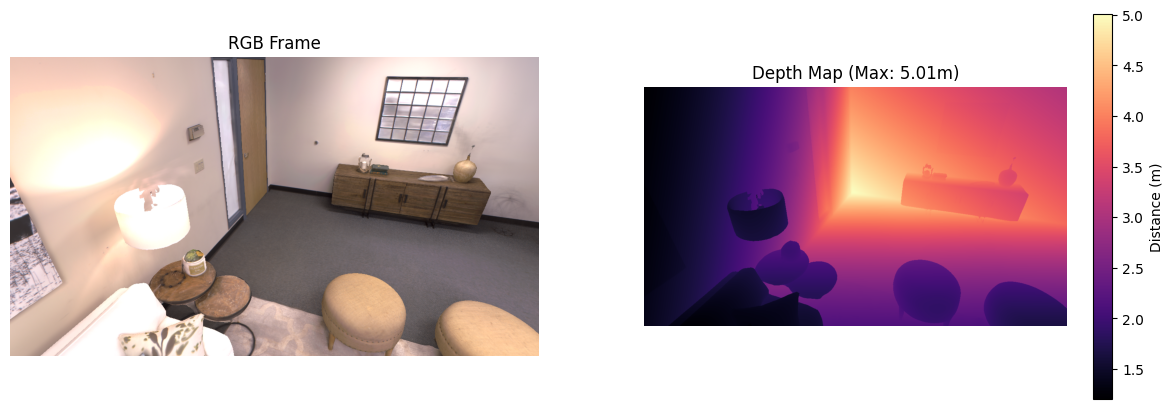

Max Raw Value: 5007
Max Metric Depth: 5.01m (Should be ~5m)
Min Metric Depth: 1.20m


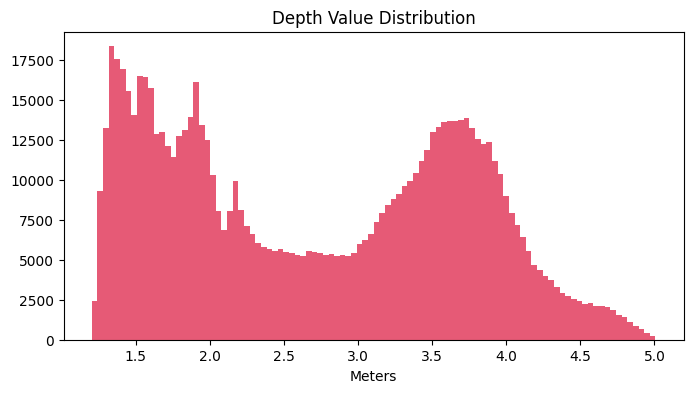

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2 

# 1. Paths
data_path = "../data/Replica/room_0/imap/00/"
rgb_path = os.path.join(data_path, "rgb/rgb_0.png")
depth_path = os.path.join(data_path, "depth/depth_0.png")

# 2. Load
rgb = plt.imread(rgb_path)
depth_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

if depth_raw is None:
    print(f"❌ Error: Could not load depth map at {depth_path}")
else:
    # --- THE FIX ---
    # Divide by 1000.0 because raw 5007 / 1000 = 5.007 meters (Correct for iMAP)
    depth_meters = depth_raw.astype(np.float32) / 1000.0
    # ---------------

    # 5. Visualization
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    ax[0].imshow(rgb)
    ax[0].set_title("RGB Frame")
    ax[0].axis('off')

    im = ax[1].imshow(depth_meters, cmap='magma')
    ax[1].set_title(f"Depth Map (Max: {depth_meters.max():.2f}m)")
    ax[1].axis('off')
    
    fig.colorbar(im, ax=ax[1], label='Distance (m)')
    plt.show()

    # 6. Verification
    print(f"Max Raw Value: {depth_raw.max()}")
    print(f"Max Metric Depth: {depth_meters.max():.2f}m (Should be ~5m)")
    print(f"Min Metric Depth: {depth_meters.min():.2f}m")
    
    # Optional: Pro-tip Histogram to see the room structure
    plt.figure(figsize=(8, 4))
    plt.hist(depth_meters.flatten(), bins=100, color='crimson', alpha=0.7)
    plt.title("Depth Value Distribution")
    plt.xlabel("Meters")
    plt.show()